In [1]:
%pip install --upgrade --only-binary=llama-cpp-python llama-cpp-python==0.3.35 huggingface-hub pillow --extra-index-url https://abetlen.github.io/llama-cpp-python/whl/cpu


Looking in indexes: https://pypi.org/simple, https://abetlen.github.io/llama-cpp-python/whl/cpu
Note: you may need to restart the kernel to use updated packages.


## 1. Data Exploration: Bilder ansehen

Die Karteikarten liegen unter `data/01_karteikarten/` in Unterordnern.
Wir zeigen zunächst bis zu acht Bilder mit Dateinamen und Originalgröße.
Mit `MAX_IMAGES` lässt sich die Anzahl der Vorschauen ändern.

Beim Anschauen: Welche Bilder zeigen **Vorderseiten**, welche **Rückseiten mit Text**,
welche **leere Seiten**? Achte auf Formularfelder, Münzabbildungen und Text.


4 Bilder gefunden; Vorschau der ersten 4:


**Abdera/Abdera-4a.jpg** — 1736 × 1752 Pixel

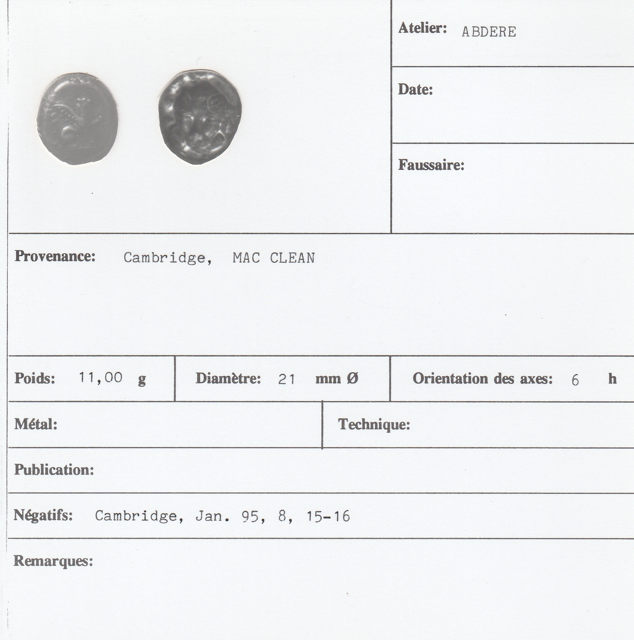

**Abdera/Abdera-4b.jpg** — 1740 × 1752 Pixel

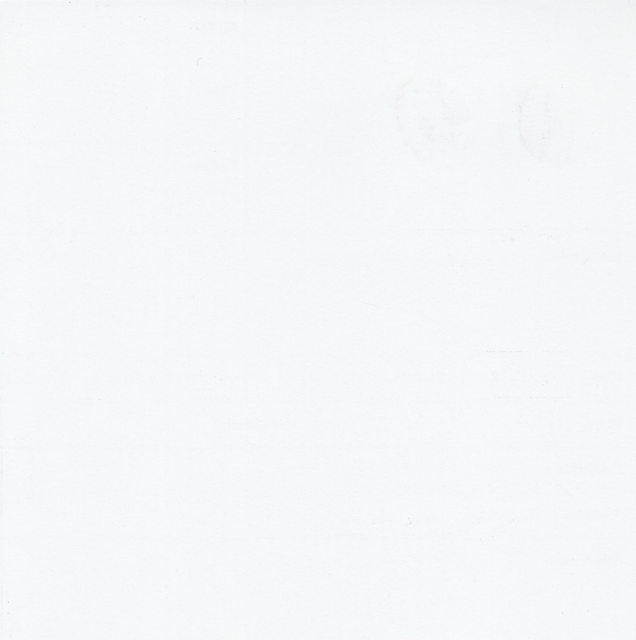

**Acanthos/Acanthos-2a.jpg** — 1732 × 1756 Pixel

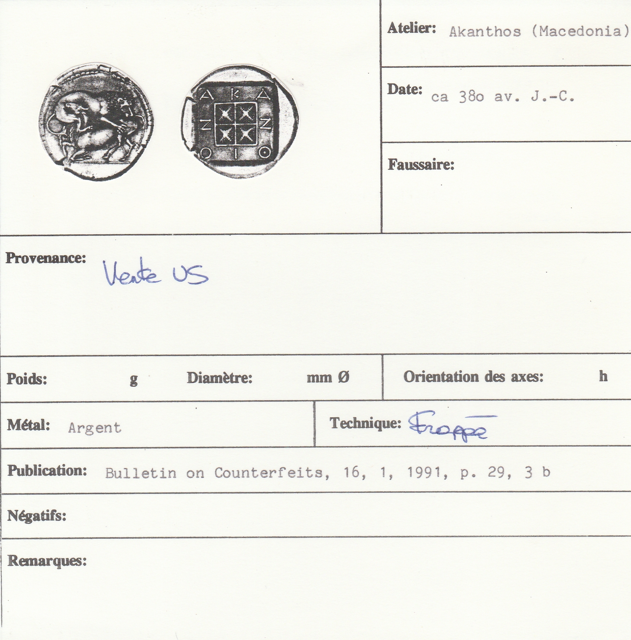

**Acanthos/Acanthos-2b.jpg** — 1736 × 1760 Pixel

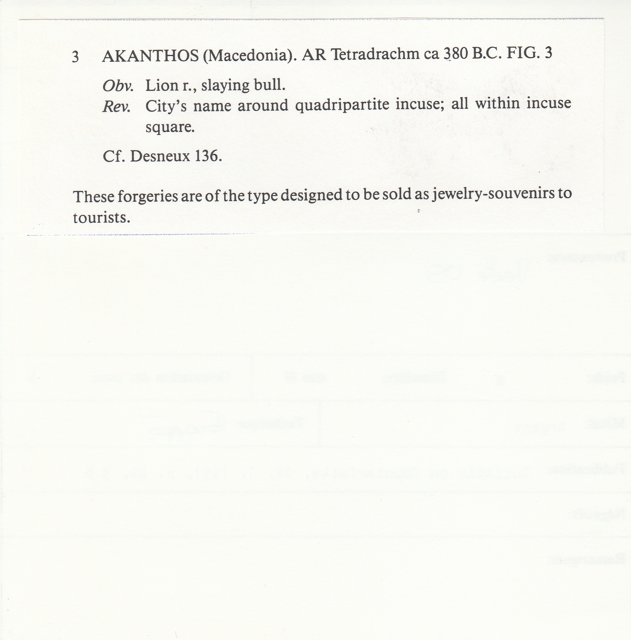

In [3]:
from pathlib import Path
from PIL import Image
from IPython.display import display, Markdown

DATA_DIR = Path("data/01_karteikarten")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".tif", ".tiff", ".webp"}
MAX_IMAGES = 8

image_paths = sorted(
    path for path in DATA_DIR.rglob("*")
    if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
)
if not image_paths:
    raise FileNotFoundError(f"Keine Bilder gefunden. Prüfe den Datenordner: {DATA_DIR.resolve()}")

print(f"{len(image_paths)} Bilder gefunden; Vorschau der ersten {min(MAX_IMAGES, len(image_paths))}:")

for image_path in image_paths[:MAX_IMAGES]:
    with Image.open(image_path) as original:
        display(Markdown(
            f"**{image_path.relative_to(DATA_DIR)}** — {original.width} × {original.height} Pixel"
        ))
        preview = original.copy()
        preview.thumbnail((640, 640))
        display(preview)


## 2. GGUF-Modell direkt im Notebook laden

Wir laden [Qwen3.5-9B-Q5_K_M.gguf](https://huggingface.co/unsloth/Qwen3.5-9B-GGUF/blob/main/Qwen3.5-9B-Q5_K_M.gguf)
mit `llama-cpp-python` direkt im Python-Kernel. Der Download dieser quantisierten Datei
beträgt **6,58 GB**. Zum Laden wird zusätzlich freier Arbeitsspeicher benötigt.

Zuerst die Installationszelle ausführen, danach die Ladezelle. Die Installation verwendet
ein fertiges CPU-Paket für diesen ersten Schritt; das Modell wird auf der CPU geladen.

Der Kontext umfasst 4096 Tokens für Bild, Prompt und vollständige JSON-Antwort.

Für die spätere Bildverarbeitung wird zusätzlich die passende `mmproj`-Datei benötigt.


In [2]:
from huggingface_hub import hf_hub_download
from llama_cpp import Llama

print("Lade GGUF-Datei herunter (6,58 GB) …", flush=True)
model_path = hf_hub_download(
    repo_id="unsloth/Qwen3.5-9B-GGUF",
    filename="Qwen3.5-9B-Q5_K_M.gguf",
)

print("Lade Modell …", flush=True)
llm = Llama(model_path=model_path, n_ctx=4096, n_gpu_layers=0, verbose=False)
print("Modell geladen.")


Lade GGUF-Datei herunter (6,58 GB) …


Lade Modell …
Modell geladen.


## 3. Bildverarbeitung vorbereiten

Die zusätzliche [mmproj-F16.gguf](https://huggingface.co/unsloth/Qwen3.5-9B-GGUF/blob/main/mmproj-F16.gguf)
enthält den Bildencoder: Er übersetzt das Bild in Eingaben für das Sprachmodell.
Der erste Download beträgt etwa **918 MB**. Wir binden ihn an das bereits geladene Modell an.
Beim ersten Bildaufruf wird auch der Bildencoder in den Arbeitsspeicher geladen.
Die Bildauswertung auf der CPU kann einige Minuten dauern.


In [4]:
import base64
import json
from functools import partial
from io import BytesIO
from llama_cpp.llama_chat_format import MTMDChatHandler

print("Lade Bildencoder herunter (ca. 918 MB) …", flush=True)
mmproj_path = hf_hub_download(
    repo_id="unsloth/Qwen3.5-9B-GGUF",
    filename="mmproj-F16.gguf",
)
vision_handler = MTMDChatHandler(clip_model_path=mmproj_path, use_gpu=False, verbose=False)
# Direkte JSON-Antwort ohne vorgeschalteten Thinking-Text.
llm.chat_handler = partial(vision_handler, enable_thinking=False)
print("Bildanbindung eingerichtet.")

def ask_image(image_url, prompt, max_tokens=512):
    response = llm.create_chat_completion(
        messages=[{
            "role": "user",
            "content": [
                {"type": "image_url", "image_url": {"url": image_url}},
                {"type": "text", "text": prompt},
            ],
        }],
        response_format={"type": "json_object"},
        temperature=0.0,
        max_tokens=max_tokens,
    )
    choice = response["choices"][0]
    if choice["finish_reason"] == "length":
        raise ValueError("JSON-Antwort abgeschnitten. max_tokens und gegebenenfalls den Modellkontext erhöhen; die Antwort wurde nicht übernommen.")
    return json.loads(choice["message"]["content"])


Lade Bildencoder herunter (ca. 918 MB) …
Bildanbindung eingerichtet.


## 4. Eine Karte auswählen

`IMAGE_INDEX = 0` wählt das erste Bild aus der Exploration. Für eine andere Karte
den Index ändern und die Schritte 4–7 erneut ausführen. Die Ergebnisse werden im
Kernel gesammelt; jedes Bild erhält eine Zeile in der Abschlusstabelle.

Für den Modellaufruf verkleinern wir eine Kopie auf höchstens 1024 × 1024 Pixel.
Unten siehst du genau diese Kopie. Kleine Schrift kann dabei schlechter lesbar werden;
fehlende oder unleserliche Kartenfelder sollen `null` bleiben.


Abdera/Abdera-4a.jpg — Modelleingabe: 1015 × 1024 Pixel


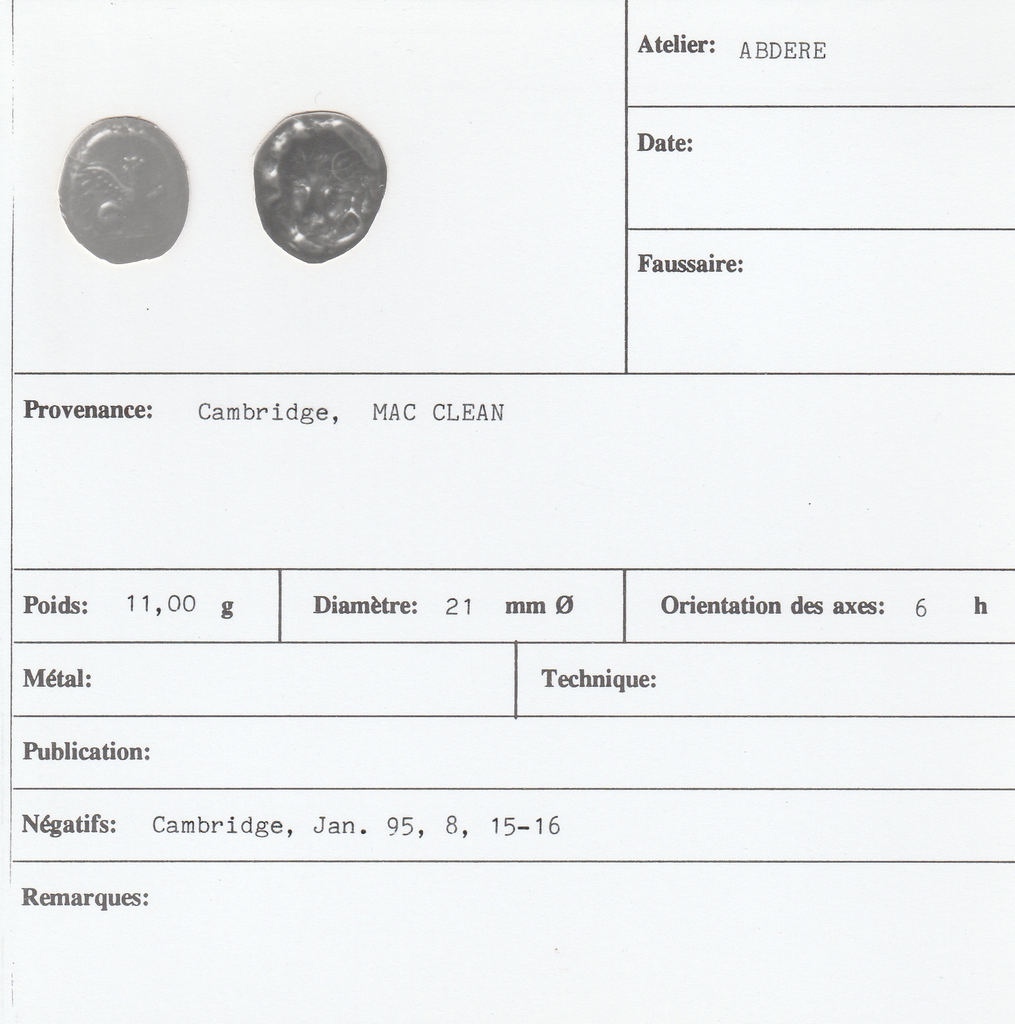

In [5]:
IMAGE_INDEX = 0
IMAGE_PATH = image_paths[IMAGE_INDEX]
answer = None
classification = None
extraction = None
result = None
df = None

# Sammlung der in dieser Sitzung bearbeiteten Bilder.
if "results" not in globals():
    results = {}

with Image.open(IMAGE_PATH) as original:
    model_image = original.convert("RGB")
model_image.thumbnail((1024, 1024), Image.Resampling.LANCZOS)
print(f"{IMAGE_PATH.relative_to(DATA_DIR)} — Modelleingabe: {model_image.width} × {model_image.height} Pixel")
display(model_image)

buffer = BytesIO()
model_image.save(buffer, format="PNG")
image_url = "data:image/png;base64," + base64.b64encode(buffer.getvalue()).decode("ascii")


## 5. Erster Modellschritt: Klassifikation als JSON

Wir verwenden die Feldnamen aus der Imagines-Nummorum-Pipeline
(`src/config/prompts.py` und `src/config/schemas.py`):

- **Vorderseite**: `image_type = "form"` — Hauptformular mit Einträgen und/oder Münzabbildungen.
- **Rückseite mit Text**: `image_type = "text_page"` — zusätzliche Notizen oder aufgeklebter Text.
- **Leere Seite**: `image_type = "empty_page"` — keine eigenen Einträge und keine Münzabbildungen.
- `handwritten_content`: Sind eigene handschriftliche Einträge sichtbar (`true` / `false`)?

Bloß durchscheinender Text und unbeschriftete Formularfelder zählen hier als leer.
Gemeint ist die Seite der **Karteikarte**, nicht Vorder- und Rückseite einer Münze.
Die nächste Zelle zeigt die angeforderte JSON-Struktur und anschließend die Modellantwort.


In [6]:
PAGE_TYPES = {
    "form": "Vorderseite",
    "text_page": "Rückseite mit Text",
    "empty_page": "Leere Seite",
}
CLASSIFICATION_JSON = {
    "image_type": "form | text_page | empty_page",
    "handwritten_content": False,
}
CLASSIFICATION_PROMPT = """Klassifiziere diese Seite einer numismatischen Karteikarte.
form: Hauptformular mit kartenspezifischen Einträgen und/oder Münzabbildungen.
text_page: Rückseite mit zusätzlichen Notizen, Text oder aufgeklebten Textauszügen.
empty_page: Keine eigenen Einträge und keine Münzabbildungen.
Ignoriere Flecken, Schatten und von der anderen Seite durchscheinenden Text.
Leere vorgedruckte Linien oder Feldnamen allein zählen als empty_page.
Sichtbarer, aber unleserlicher eigener Text zählt als Text.
Die Klassen beziehen sich auf die Karteikarte, nicht auf die Münze.
Setze image_type auf genau einen der drei Werte.
Setze handwritten_content auf true, wenn eigene Handschrift sichtbar ist, sonst false.
Antworte nur als JSON mit genau diesen Feldern:
""" + json.dumps(CLASSIFICATION_JSON, ensure_ascii=False, indent=2)

classification = None
extraction = None
result = None
df = None
print("Angeforderte JSON-Struktur:")
print(json.dumps(CLASSIFICATION_JSON, ensure_ascii=False, indent=2))
print("Klassifiziere die Karte …", flush=True)
answer = ask_image(image_url, CLASSIFICATION_PROMPT, max_tokens=256)
print("Modellantwort:")
print(json.dumps(answer, ensure_ascii=False, indent=2))
if not isinstance(answer, dict) or set(answer) != set(CLASSIFICATION_JSON):
    raise ValueError("Erwartet: image_type und handwritten_content.")
if not isinstance(answer["image_type"], str) or answer["image_type"] not in PAGE_TYPES:
    raise ValueError(f"Unbekannter Seitentyp: {answer['image_type']}")
if not isinstance(answer["handwritten_content"], bool):
    raise ValueError("handwritten_content muss true oder false sein.")
classification = answer
print(PAGE_TYPES[classification["image_type"]])


Angeforderte JSON-Struktur:
{
  "image_type": "form | text_page | empty_page",
  "handwritten_content": false
}
Klassifiziere die Karte …


tokenize: no merging for part index 1
add_text: <|im_start|>user

add_text: <|vision_start|>
add_media: preproc_out has 1 entries, grid_x = 0, grid_y = 0, has_overview = 0
image_tokens->nx = 32
image_tokens->ny = 32
batch_f32 size = 1
add_text: <|vision_end|>
add_text: Klassifiziere diese Seite einer numismatischen Karteikarte.
form: Hauptformular mit kartenspezifischen Einträgen und/oder Münzabbildungen.
text_page: Rückseite mit zusätzlichen Notizen, Text oder aufgeklebten Textauszügen.
empty_page: Keine eigenen Einträge und keine Münzabbildungen.
Ignoriere Flecken, Schatten und von der anderen Seite durchscheinenden Text.
Leere vorgedruckte Linien oder Feldnamen allein zählen als empty_page.
Sichtbarer, aber unleserlicher eigener Text zählt als Text.
Die Klassen beziehen sich auf die Karteikarte, nicht auf die Münze.
Setze image_type auf genau einen der drei Werte.
Setze handwritten_content auf true, wenn eigene Handschrift sichtbar ist, sonst false.
Antworte nur als JSON mit genau d

Modellantwort:
{
  "image_type": "form",
  "handwritten_content": false
}
Vorderseite


## 6. Zweiter Modellschritt: vollständige Extraktions-JSONs

Die folgenden Strukturen übernehmen die ursprünglichen VLM-Felder aus
`src/config/prompts.py` und `src/config/schemas.py` der Imagines-Nummorum-Pipeline:

- **Vorderseite:** `card_fields` mit allen zwölf französischen Formularfeldern und
  `coins` mit Kennung, Beschreibung und `bbox_2d` für jede Münzabbildung.
- **Textrückseite:** `extracted_text` mit dem vollständigen Text in der Quellsprache.
- **Leere Seite:** kein weiterer Modellaufruf; `extraction` bleibt `null`.

`bbox_2d` enthält `[x1, y1, x2, y2]` als ganze Zahlen auf einer **Skala von 0 bis 1000**:
links oben bis rechts unten. Die Zahlen in der Vorlage zeigen nur das Ausgabeformat.
Diese Koordinaten beziehen sich auf das ganze Bild und sind keine Pixelwerte.
Kartenfelder enthalten Text oder `null`; Einheiten und Schreibweisen bleiben erhalten.
Als Text gelieferte ganze Zahlen wie `"62"` werden vor der Prüfung in Zahlen umgewandelt.

Für die längeren JSON-Antworten verwenden wir einen Kontext von 4096 Tokens.
Falls noch das Modell mit 2048 Tokens geladen ist, wird es einmal aus der vorhandenen
GGUF-Datei mit dem größeren Kontext neu geladen.


In [7]:
FORM_JSON = {
    "coins": [
        {
            "id": "coin_1",
            "description": "kurze Beschreibung der sichtbaren Münzabbildung",
            "bbox_2d": [100, 100, 300, 300],
        }
    ],
    "card_fields": {
        "Atelier": None,
        "Date": None,
        "Faussaire": None,
        "Provenance": None,
        "Poids": None,
        "Diamètre": None,
        "Orientation des axes": None,
        "Métal": None,
        "Technique": None,
        "Publication": None,
        "Négatifs": None,
        "Remarques": None,
    },
}
TEXT_JSON = {"extracted_text": "vollständiger Text der Seite"}

FORM_PROMPT = """Lies diese numismatische Karteikarte.
Extrahiere alle zwölf card_fields wortgetreu aus den zugehörigen Formularfeldern.
Fehlende oder unleserliche Werte bleiben null. Erhalte Einheiten und Schreibweisen.
Ergänze kein Weltwissen und keine Informationen von der anderen Kartenseite.
Ignoriere durchscheinenden Text. Erfasse in coins jede sichtbare Münzabbildung.
Vergib eindeutige IDs coin_1, coin_2 usw. Beschreibe das sichtbare Motiv jeweils kurz.
bbox_2d: [x1,y1,x2,y2] als ganze Zahlen von 0 bis 1000, relativ zum ganzen Bild;
links oben bis rechts unten, x1 < x2 und y1 < y2. Ohne Münzabbildungen: coins = [].
Koordinaten sind JSON-Zahlen ohne Anführungszeichen. Bestimme sie aus dem Bild;
die Koordinaten in der Vorlage sind nur ein Formatbeispiel.
Antworte ausschließlich als JSON mit genau dieser Struktur und allen Kartenfeldern:
""" + json.dumps(FORM_JSON, ensure_ascii=False, indent=2)

TEXT_PROMPT = """Transkribiere den gesamten sichtbaren Text dieser Kartenseite.
Erhalte Quellsprache, Schreibweisen und Zeilenumbrüche. Fasse den Text nicht zusammen.
Markiere unleserliche Stellen mit [unleserlich]. Ergänze kein Weltwissen.
Ignoriere Text, der nur von der anderen Seite durchscheint.
Antworte ausschließlich als JSON mit genau dieser Struktur:
""" + json.dumps(TEXT_JSON, ensure_ascii=False, indent=2)

print("Angeforderte JSON-Struktur für Vorderseiten:")
print(json.dumps(FORM_JSON, ensure_ascii=False, indent=2))
print("Angeforderte JSON-Struktur für Textrückseiten:")
print(json.dumps(TEXT_JSON, ensure_ascii=False, indent=2))


Angeforderte JSON-Struktur für Vorderseiten:
{
  "coins": [
    {
      "id": "coin_1",
      "description": "kurze Beschreibung der sichtbaren Münzabbildung",
      "bbox_2d": [
        100,
        100,
        300,
        300
      ]
    }
  ],
  "card_fields": {
    "Atelier": null,
    "Date": null,
    "Faussaire": null,
    "Provenance": null,
    "Poids": null,
    "Diamètre": null,
    "Orientation des axes": null,
    "Métal": null,
    "Technique": null,
    "Publication": null,
    "Négatifs": null,
    "Remarques": null
  }
}
Angeforderte JSON-Struktur für Textrückseiten:
{
  "extracted_text": "vollständiger Text der Seite"
}


In [8]:
import re
from copy import deepcopy

def validate_extraction(answer, image_type):
    """Gibt eine geprüfte Kopie mit numerischen Münzkoordinaten zurück."""
    if not isinstance(answer, dict):
        raise ValueError("Die Extraktion muss ein JSON-Objekt sein.")
    answer = deepcopy(answer)
    if image_type == "text_page":
        if set(answer) != set(TEXT_JSON) or not isinstance(answer["extracted_text"], str):
            raise ValueError("Erwartet: extracted_text als Text.")
        return answer

    if set(answer) != set(FORM_JSON):
        raise ValueError("Erwartet: coins und card_fields.")
    fields = answer["card_fields"]
    if not isinstance(fields, dict) or set(fields) != set(FORM_JSON["card_fields"]):
        raise ValueError("card_fields muss genau die zwölf angeforderten Felder enthalten.")
    for name, value in fields.items():
        if value is not None and not isinstance(value, str):
            raise ValueError(f"{name} muss Text oder null sein.")
    if not isinstance(answer["coins"], list):
        raise ValueError("coins muss eine Liste sein.")
    coin_ids = set()
    for coin in answer["coins"]:
        if not isinstance(coin, dict) or set(coin) != {"id", "description", "bbox_2d"}:
            raise ValueError("Jede Münze benötigt id, description und bbox_2d.")
        if not isinstance(coin["id"], str) or not coin["id"].strip() or coin["id"] in coin_ids:
            raise ValueError("Münz-IDs müssen eindeutige, nichtleere Texte sein.")
        coin_ids.add(coin["id"])
        if not isinstance(coin["description"], str):
            raise ValueError("Die Münzbeschreibung muss Text sein.")
        bbox = coin["bbox_2d"]
        if not isinstance(bbox, list) or len(bbox) != 4:
            raise ValueError("bbox_2d benötigt vier ganze Zahlen.")
        bbox = [
            int(v) if isinstance(v, str) and re.fullmatch(r"[+-]?[0-9]+", v.strip()) else v
            for v in bbox
        ]
        if any(type(v) is not int for v in bbox):
            raise ValueError(f"bbox_2d benötigt vier ganze Zahlen; erhalten: {bbox}")
        x1, y1, x2, y2 = bbox
        if not (0 <= x1 < x2 <= 1000 and 0 <= y1 < y2 <= 1000):
            raise ValueError(f"Ungültige Münzkoordinaten: {bbox}")
        coin["bbox_2d"] = bbox
    return answer


In [9]:
answer = None
extraction = None
result = None
df = None
if classification is None:
    raise ValueError("Bitte zuerst die Klassifikationszelle ausführen.")

image_type = classification["image_type"]
if image_type == "empty_page":
    print("Leere Seite: Extraktion übersprungen.")
else:
    if llm.n_ctx() < 4096:
        print("Lade das Modell mit größerem Kontext aus der vorhandenen GGUF-Datei …", flush=True)
        llm.close()
        llm = Llama(model_path=model_path, n_ctx=4096, n_gpu_layers=0, verbose=False)
        llm.chat_handler = partial(vision_handler, enable_thinking=False)
    prompt = FORM_PROMPT if image_type == "form" else TEXT_PROMPT
    print("Extrahiere das vollständige JSON …", flush=True)
    answer = ask_image(image_url, prompt, max_tokens=2048)
    print("Modellantwort:")
    print(json.dumps(answer, ensure_ascii=False, indent=2))


Extrahiere das vollständige JSON …


tokenize: no merging for part index 1
add_text: <|im_start|>user

add_text: <|vision_start|>
add_media: preproc_out has 1 entries, grid_x = 0, grid_y = 0, has_overview = 0
image_tokens->nx = 32
image_tokens->ny = 32
batch_f32 size = 1
add_text: <|vision_end|>
add_text: Lies diese numismatische Karteikarte.
Extrahiere alle zwölf card_fields wortgetreu aus den zugehörigen Formularfeldern.
Fehlende oder unleserliche Werte bleiben null. Erhalte Einheiten und Schreibweisen.
Ergänze kein Weltwissen und keine Informationen von der anderen Kartenseite.
Ignoriere durchscheinenden Text. Erfasse in coins jede sichtbare Münzabbildung.
Vergib eindeutige IDs coin_1, coin_2 usw. Beschreibe das sichtbare Motiv jeweils kurz.
bbox_2d: [x1,y1,x2,y2] als ganze Zahlen von 0 bis 1000, relativ zum ganzen Bild;
links oben bis rechts unten, x1 < x2 und y1 < y2. Ohne Münzabbildungen: coins = [].
Koordinaten sind JSON-Zahlen ohne Anführungszeichen. Bestimme sie aus dem Bild;
die Koordinaten in der Vorlage sind n

Modellantwort:
{
  "coins": [
    {
      "id": "coin_1",
      "description": "Münzseite mit Profil eines Mannes (wahrscheinlich Herrscher), rechts von ihm ein Adler oder ähnliches Tier",
      "bbox_2d": [
        60,
        112,
        188,
        256
      ]
    },
    {
      "id": "coin_2",
      "description": "Münzseite mit Profil eines Mannes (wahrscheinlich Herrscher), umgeben von ornamentalem Rand",
      "bbox_2d": [
        250,
        107,
        382,
        254
      ]
    }
  ],
  "card_fields": {
    "Atelier": "ABDERE",
    "Date": null,
    "Faussaire": null,
    "Provenance": "Cambridge, MAC CLEAN",
    "Poids": "11,00 g",
    "Diamètre": "21 mm Ø",
    "Orientation des axes": "6 h",
    "Métal": null,
    "Technique": null,
    "Publication": null,
    "Négatifs": "Cambridge, Jan. 95, 8, 15-16",
    "Remarques": null
  }
}


### JSON prüfen und sammeln

Diese Zelle verarbeitet die bereits erzeugte Antwort in `answer`.
Nach einer Anpassung der Prüffunktion kann sie erneut ausgeführt werden.
Die rohe Modellantwort bleibt erhalten; in die Tabelle kommt die geprüfte Kopie
mit numerischen Koordinaten.


In [10]:
extraction = None
result = None
df = None
if classification is None:
    raise ValueError("Bitte zuerst die Klassifikationszelle ausführen.")
image_type = classification["image_type"]
if image_type != "empty_page":
    if answer is None:
        raise ValueError("Bitte zuerst die Extraktionszelle ausführen.")
    extraction = validate_extraction(answer, image_type)

# Quelldatei und Klassifikation ergänzen die geprüfte Extraktionsantwort.
result = {
    "image_path_original": str(IMAGE_PATH),
    **classification,
    "extraction": extraction,
}
results[str(IMAGE_PATH)] = result
print(f"{len(results)} Bild(er) für die Tabelle gesammelt.")


1 Bild(er) für die Tabelle gesammelt.


### Ergebnis am Bild prüfen

Stimmen Klassifikation, Kartenfelder, Münzbeschreibungen und Transkription mit der Quelle überein?
Hat das Modell etwas ergänzt, das nicht lesbar ist? Bei kleinen Schriftzügen auch das Original ansehen.
Die Prüfungen kontrollieren Feldnamen, Datentypen und Koordinatengrenzen.
Ein formal gültiges JSON bleibt ein Erschließungsvorschlag zur Prüfung.


## 7. Ergebnisse als DataFrame und Tabelle

`results` enthält die vollständigen Ergebnisse der bisher bearbeiteten Bilder.
`pd.json_normalize` macht aus den verschachtelten Kartenfeldern einzelne Spalten.
**Eine Zeile entspricht einem Bild.** Die zwölf Kartenfelder, der vollständige Text
und die Münzliste einschließlich Bildkoordinaten bleiben im DataFrame `df` erhalten.
Leere Seiten erhalten ebenfalls eine Zeile mit ihrer Klassifikation.

Für weitere Bilder den Index in Schritt 4 ändern und die Schritte 4–7 erneut ausführen.
Ein erfolgreicher neuer Durchlauf desselben Bildes ersetzt dessen bisherigen Eintrag.
Die Tabelle zeigt damit jeweils das letzte erfolgreich geprüfte Ergebnis.


In [11]:
%pip install pandas


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 83.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [12]:
import pandas as pd

if not results:
    raise ValueError("Bitte zuerst eine Karte klassifizieren und Schritt 6 ausführen.")

df = pd.json_normalize(list(results.values()))
df = df.rename(columns=lambda name: name.removeprefix("extraction.card_fields.").removeprefix("extraction."))
df = df.reindex(columns=[
    "image_path_original", "image_type", "handwritten_content",
    *FORM_JSON["card_fields"], "extracted_text", "coins",
])

with pd.option_context("display.max_columns", None, "display.max_colwidth", None, "display.max_seq_items", None):
    display(df)


,image_path_original,image_type,handwritten_content,Atelier,Date,Faussaire,Provenance,Poids,Diamètre,Orientation des axes,Métal,Technique,Publication,Négatifs,Remarques,extracted_text,coins
0,data/01_karteikarten/Abdera/Abdera-4a.jpg,form,False,ABDERE,None,None,"Cambridge, MAC CLEAN","11,00 g",21 mm Ø,6 h,None,None,None,"Cambridge, Jan. 95, 8, 15-16",None,NaN,"[{'id': 'coin_1', 'description': 'Münzseite mit Profil eines Mannes (wahrscheinlich Herrscher), rechts von ihm ein Adler oder ähnliches Tier', 'bbox_2d': [60, 112, 188, 256]}, {'id': 'coin_2', 'description': 'Münzseite mit Profil eines Mannes (wahrscheinlich Herrscher), umgeben von ornamentalem Rand', 'bbox_2d': [250, 107, 382, 254]}]"
